# Basic data analysis (parquet overview + core plots)

This notebook is intentionally **basic EDA**:
- quick schema/health checks (`info`, `head`, `describe`) for each parquet
- simple plots:
  1. boxplots for daily quantity distribution
  2. line plots: quantity vs temperature and vs precipitation (binned)
  3. bubble chart: average monthly quantity per product (top-N)

**No PDF reports. All outputs are displayed inside this notebook only.**

## Memory note
Full store×product×day joins can be RAM-heavy. This notebook keeps memory under control by:
- aggregating early (daily totals, store-day totals)
- limiting bubble chart to top-N products


In [1]:
# --- Imports
from __future__ import annotations

import io
import os
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1) Project root + paths

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "raw_data").exists() and (p / "src").exists():
            return p
    raise RuntimeError(f"Project root not found above: {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
RAW_DIR = PROJECT_ROOT / "raw_data"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)


PROJECT_ROOT: C:\Users\simon\food_prediction
RAW_DIR: C:\Users\simon\food_prediction\raw_data


## 2) Load latest parquet files

In [3]:
def pick_latest_file(folder: Path, pattern: str) -> Path:
    matches = sorted(folder.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No files found: {folder} / {pattern}")
    return matches[-1]


FILES = {
    "sales": pick_latest_file(RAW_DIR, "*_sales_data.parquet"),
    "weather": pick_latest_file(RAW_DIR, "*_weather.parquet"),
    "stores": pick_latest_file(RAW_DIR, "*_stores.parquet"),
    "holidays": pick_latest_file(RAW_DIR, "*_holidays.parquet"),
}
FILES


{'sales': WindowsPath('C:/Users/simon/food_prediction/raw_data/20260218_144523_sales_data.parquet'),
 'weather': WindowsPath('C:/Users/simon/food_prediction/raw_data/20260218_144523_weather.parquet'),
 'stores': WindowsPath('C:/Users/simon/food_prediction/raw_data/20260218_144523_stores.parquet'),
 'holidays': WindowsPath('C:/Users/simon/food_prediction/raw_data/20260218_144523_holidays.parquet')}

## 3) Quick tables per parquet: `info`, `head(5)`, `describe()`

`DataFrame.info()` prints to stdout, so we capture it as a string for display.


In [4]:
def df_info_string(df: pd.DataFrame) -> str:
    buf = io.StringIO()
    df.info(buf=buf)
    return buf.getvalue()


dfs: Dict[str, pd.DataFrame] = {}
for name, path in FILES.items():
    df = pd.read_parquet(path)
    dfs[name] = df

    print("=" * 90)
    print(f"{name.upper()}  ->  {path.name}")
    print(df_info_string(df))

    display(df.head(5))
    display(df.describe(include="all"))


SALES  ->  20260218_144523_sales_data.parquet
<class 'pandas.DataFrame'>
RangeIndex: 713637 entries, 0 to 713636
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           713637 non-null  datetime64[ns]
 1   category_name  713637 non-null  str           
 2   item_id        713637 non-null  int64         
 3   sold_quantity  713637 non-null  float64       
 4   price          696648 non-null  float64       
 5   store_id       713637 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), str(1)
memory usage: 38.8 MB



,date,category_name,item_id,sold_quantity,price,store_id
0,2025-04-01,Angebot Brötchen,139,15.0,0.0,0
1,2025-04-01,Angebot Feinbäckerei,138,28.0,0.0,0
2,2025-04-01,Angebot Heißgetränke,106,25.0,0.0,0
3,2025-04-01,Angebot Heißgetränke,539,5.0,1.4,0
4,2025-04-01,Angebot Snack,176,1.0,0.0,0


,date,category_name,item_id,sold_quantity,price,store_id
count,713637,713637,713637.000000,713637.000000,696648.000000,713637.000000
unique,NaN,23,NaN,NaN,NaN,NaN
top,NaN,Brötchen,NaN,NaN,NaN,NaN
freq,NaN,195190,NaN,NaN,NaN,NaN
mean,2025-05-15 16:04:01.050282240,NaN,262.957623,15.845915,2.747405,30.802189
min,2025-04-01 00:00:00,NaN,0.000000,-1.000000,-22.000000,0.000000
25%,2025-04-24 00:00:00,NaN,67.000000,1.000000,1.100000,14.000000
50%,2025-05-16 00:00:00,NaN,220.000000,4.000000,2.600000,30.000000
75%,2025-06-07 00:00:00,NaN,449.000000,12.000000,3.800000,46.000000
max,2025-06-30 00:00:00,NaN,676.000000,2425.000000,115.000000,83.000000


WEATHER  ->  20260218_144523_weather.parquet
<class 'pandas.DataFrame'>
RangeIndex: 78624 entries, 0 to 78623
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 78624 non-null  datetime64[ns]
 1   time                 78624 non-null  str           
 2   zipcode              78624 non-null  str           
 3   temperature          78624 non-null  float64       
 4   wind_speed           78624 non-null  float64       
 5   wind_degree          78624 non-null  float64       
 6   wind_dir             78624 non-null  str           
 7   weather_code         78624 non-null  int64         
 8   weather_description  78624 non-null  str           
 9   precip               78624 non-null  float64       
 10  humidity             78624 non-null  float64       
 11  visibility           78624 non-null  float64       
 12  pressure             78624 non-null  float64       
 1

,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_code,weather_description,precip,...,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
0,2025-04-01,20:00,41812,10.0,16.0,79.0,ENE,113,Clear,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2025-04-01,21:00,41812,9.0,16.0,75.0,ENE,113,Clear,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2025-04-01,22:00,41812,9.0,18.0,71.0,ENE,113,Clear,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2025-04-01,23:00,41812,8.0,20.0,70.0,ENE,113,Clear,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2025-04-01,00:00,41812,6.0,10.0,52.0,NE,113,Clear,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


...

,subdivision_code,country_code,zipcode,average_weekly_revenue_Q1,store_id
0,DE-NW,DE,52062,21448.248159,0
1,DE-NW,DE,52224,17844.961211,1
2,DE-NW,DE,52134,12808.989643,2
3,DE-NW,DE,52062,7635.616974,3
4,DE-NW,DE,52222,21000.922881,4


,subdivision_code,country_code,zipcode,average_weekly_revenue_Q1,store_id
count,84,84,84,84.000000,84.000000
unique,1,1,36,NaN,NaN
top,DE-NW,DE,52064,NaN,NaN
freq,84,84,5,NaN,NaN
mean,NaN,NaN,NaN,13474.966931,41.500000
std,NaN,NaN,NaN,10001.293301,24.392622
min,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,0.000000,20.750000
50%,NaN,NaN,NaN,15077.306829,41.500000
75%,NaN,NaN,NaN,20770.518048,62.250000


HOLIDAYS  ->  20260218_144523_holidays.parquet
<class 'pandas.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   zipcode           1301 non-null   str           
 1   subdivision_code  1301 non-null   str           
 2   date              1301 non-null   datetime64[ns]
 3   holiday_name      1301 non-null   str           
 4   holiday_type      1301 non-null   str           
dtypes: datetime64[ns](1), str(4)
memory usage: 93.7 KB



,zipcode,subdivision_code,date,holiday_name,holiday_type
0,41812,DE-NW,2025-04-01,Zuckerfest,special_day
1,41812,DE-NW,2025-04-02,Zuckerfest,special_day
2,41812,DE-NW,2025-04-12,Osterferien,school_holiday
3,41812,DE-NW,2025-04-13,Osterferien,school_holiday
4,41812,DE-NW,2025-04-13,Palmsonntag,special_day


,zipcode,subdivision_code,date,holiday_name,holiday_type
count,1301,1301,1301,1301,1301
unique,36,2,NaN,19,3
top,52531,DE-NW,NaN,Osterferien,school_holiday
freq,76,1260,NaN,598,635
mean,NaN,NaN,2025-05-01 14:05:37.586471936,NaN,NaN
min,NaN,NaN,2025-04-01 00:00:00,NaN,NaN
25%,NaN,NaN,2025-04-17 00:00:00,NaN,NaN
50%,NaN,NaN,2025-04-22 00:00:00,NaN,NaN
75%,NaN,NaN,2025-05-11 00:00:00,NaN,NaN
max,NaN,NaN,2025-06-24 00:00:00,NaN,NaN


## 4) Prepare core analytic frames (lightweight)

In [5]:
sales = dfs["sales"].copy()
weather = dfs["weather"].copy()

# Standardize sales columns
sales["date"] = pd.to_datetime(sales["date"])
sales = sales.rename(columns={"item_id": "product_id", "sold_quantity": "qty"})

required_sales = {"date", "store_id", "product_id", "category_name", "qty"}
missing_sales = required_sales - set(sales.columns)
if missing_sales:
    raise ValueError(f"Sales missing columns: {missing_sales}. Available: {list(sales.columns)}")

daily_total = sales.groupby("date", as_index=False)["qty"].sum()
daily_total["dow"] = daily_total["date"].dt.day_name().str[:3]

display(daily_total.head())


,date,qty,dow
0,2025-04-01,117712.513,Tue
1,2025-04-02,126960.022,Wed
2,2025-04-03,119329.011,Thu
3,2025-04-04,132342.165,Fri
4,2025-04-05,183285.033,Sat


## 5) Boxplots: distribution of total quantity per day

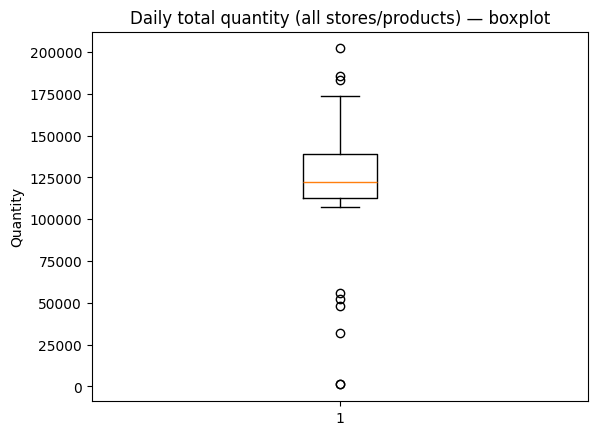

C:\Users\simon\AppData\Local\Temp\ipykernel_23152\3434718776.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_dow, labels=order, vert=True)


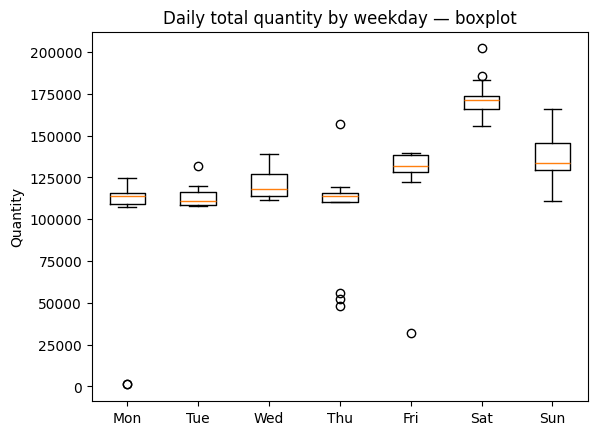

In [6]:
plt.figure()
plt.boxplot(daily_total["qty"].values, vert=True)
plt.title("Daily total quantity (all stores/products) — boxplot")
plt.ylabel("Quantity")
plt.show()

order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
data_by_dow = [daily_total.loc[daily_total["dow"] == d, "qty"].values for d in order]

plt.figure()
plt.boxplot(data_by_dow, labels=order, vert=True)
plt.title("Daily total quantity by weekday — boxplot")
plt.ylabel("Quantity")
plt.show()


## 6) Quantity vs weather (temperature / precipitation)

We join **store-day** sales totals with **store-day** weather, then bin the weather variables
and plot mean quantity per bin as a simple curve.

This is descriptive EDA only (no causal claim).


In [7]:
# Standardize weather date column (robust)
if "date" in weather.columns:
    weather["date"] = pd.to_datetime(weather["date"])
elif "datetime" in weather.columns:
    weather["date"] = pd.to_datetime(weather["datetime"]).dt.normalize()
else:
    raise ValueError(f"Weather parquet has no 'date' or 'datetime' column. Available: {list(weather.columns)}")

# Infer temperature and precipitation columns
possible_temp = [c for c in weather.columns if c.lower() in {"temp", "temperature", "tavg", "tmean", "temp_c", "temp_mean"}]
possible_prec = [c for c in weather.columns if c.lower() in {"prcp", "precip", "precipitation", "rain", "rain_mm", "precip_mm"}]

if not possible_temp:
    possible_temp = [c for c in weather.columns if "temp" in c.lower()]
if not possible_prec:
    possible_prec = [c for c in weather.columns if any(k in c.lower() for k in ["prcp", "precip", "rain"])]

TEMP_COL = possible_temp[0] if possible_temp else None
PREC_COL = possible_prec[0] if possible_prec else None

print("Inferred TEMP_COL:", TEMP_COL)
print("Inferred PREC_COL:", PREC_COL)

store_day_sales = sales.groupby(["date", "store_id"], as_index=False)["qty"].sum()

join_keys = ["date"]
if "store_id" in weather.columns:
    join_keys = ["date", "store_id"]

wd = weather.copy()
keep_cols = join_keys + [c for c in [TEMP_COL, PREC_COL] if c is not None]
wd = wd[keep_cols].drop_duplicates(subset=join_keys)

joined = store_day_sales.merge(wd, on=join_keys, how="inner")
display(joined.head())
print("Joined rows:", len(joined))


Inferred TEMP_COL: temperature
Inferred PREC_COL: precip


,date,store_id,qty,temperature,precip
0,2025-04-01,0,2878.150,10.0,0.0
1,2025-04-01,1,2227.584,10.0,0.0
2,2025-04-01,2,1315.500,10.0,0.0
3,2025-04-01,3,1668.585,10.0,0.0
4,2025-04-01,4,2971.653,10.0,0.0


Joined rows: 7058


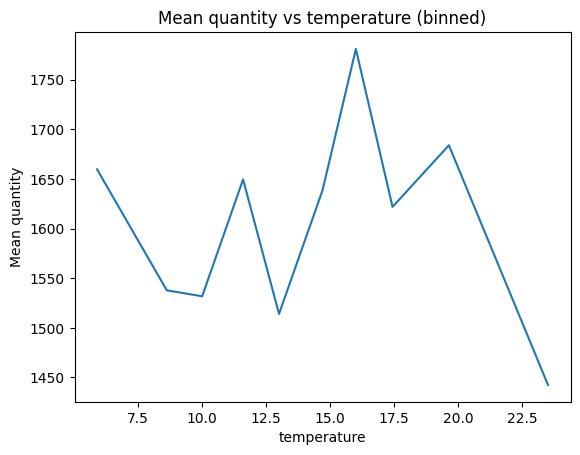

,bin,x_mean,y_mean,n
0,"(2.999, 7.0]",5.897059,1659.636847,816
1,"(7.0, 9.0]",8.619048,1537.752939,819
2,"(9.0, 10.0]",10.000000,1531.755789,778
3,"(10.0, 12.0]",11.597130,1649.503211,906
4,"(12.0, 13.0]",13.000000,1513.977614,840
5,"(13.0, 15.0]",14.698671,1638.530644,677
6,"(15.0, 16.0]",16.000000,1780.932872,539
7,"(16.0, 18.0]",17.431535,1621.834364,723
8,"(18.0, 20.0]",19.631579,1683.874272,456
9,"(20.0, 26.0]",23.500000,1442.479774,504


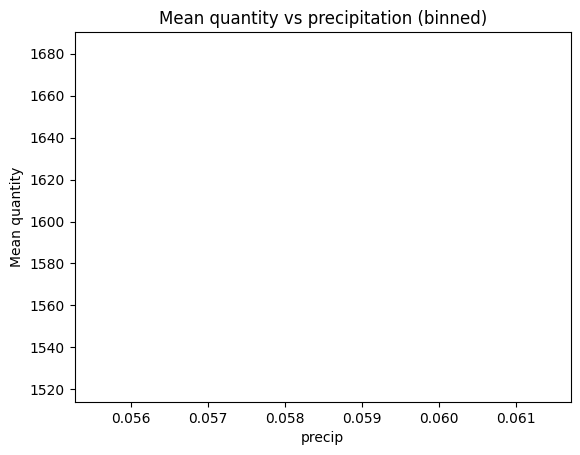

,bin,x_mean,y_mean,n
0,"(-0.001, 2.3]",0.058487,1602.186344,7058


In [8]:
def plot_binned_mean(x: pd.Series, y: pd.Series, n_bins: int, title: str, xlabel: str):
    mask = x.notna() & y.notna()
    x = x[mask].astype(float)
    y = y[mask].astype(float)

    if len(x) == 0:
        print(f"Skipping plot (no data): {title}")
        return

    bins = pd.qcut(x, q=n_bins, duplicates="drop")
    g = pd.DataFrame({"bin": bins, "x": x, "y": y}).groupby("bin", as_index=False).agg(
        x_mean=("x", "mean"),
        y_mean=("y", "mean"),
        n=("y", "size"),
    )

    plt.figure()
    plt.plot(g["x_mean"].values, g["y_mean"].values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Mean quantity")
    plt.show()

    display(g)


if TEMP_COL is not None:
    plot_binned_mean(joined[TEMP_COL], joined["qty"], n_bins=12, title="Mean quantity vs temperature (binned)", xlabel=TEMP_COL)

if PREC_COL is not None:
    plot_binned_mean(joined[PREC_COL], joined["qty"], n_bins=12, title="Mean quantity vs precipitation (binned)", xlabel=PREC_COL)


## 7) Bubble chart: average monthly quantity per product (top-N)

Bubble chart setup:
- x-axis: month
- y-axis: product_id (top-N products by total volume)
- bubble size: monthly quantity for that product


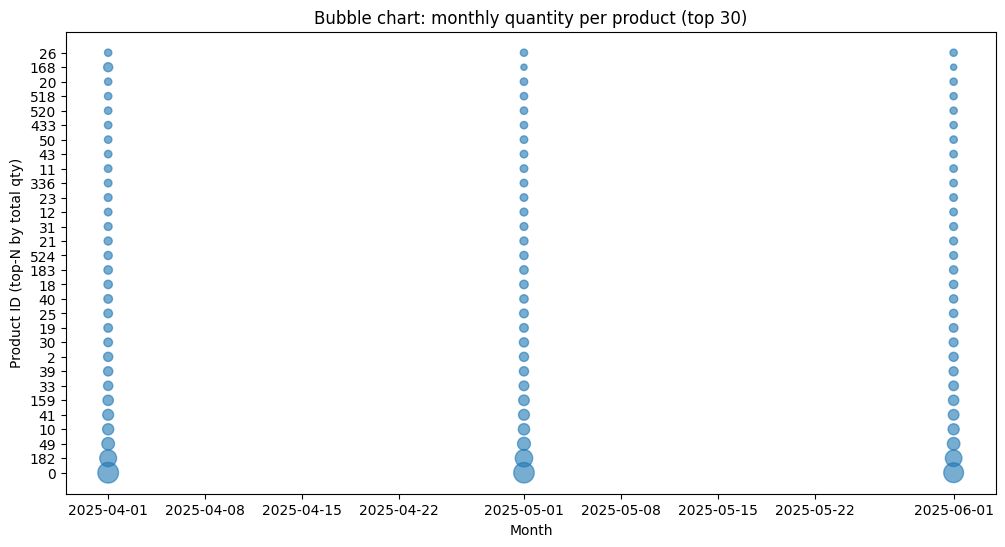

,month,product_id,qty,y
0,2025-04-01,0,641969.25,0
2,2025-04-01,2,76816.00,8
10,2025-04-01,10,142602.77,3
11,2025-04-01,11,31506.00,21
12,2025-04-01,12,32169.00,18
17,2025-04-01,18,53329.00,13
18,2025-04-01,19,58523.00,10
19,2025-04-01,20,25529.00,27
20,2025-04-01,21,44438.00,16
21,2025-04-01,23,37159.00,19


In [9]:
TOP_N_PRODUCTS = 30  # keep plot readable; raise only if you accept heavy clutter

sales_m = sales.copy()
sales_m["month"] = sales_m["date"].dt.to_period("M").dt.to_timestamp()

monthly_product = sales_m.groupby(["month", "product_id"], as_index=False)["qty"].sum()

top_products = (
    monthly_product.groupby("product_id")["qty"].sum().sort_values(ascending=False).head(TOP_N_PRODUCTS).index.tolist()
)
mp_top = monthly_product[monthly_product["product_id"].isin(top_products)].copy()

pid_to_y = {pid: i for i, pid in enumerate(top_products)}
mp_top["y"] = mp_top["product_id"].map(pid_to_y)

sizes = mp_top["qty"].astype(float).values
size_scaled = 20 + 200 * (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-9) if len(sizes) else sizes

plt.figure(figsize=(12, 6))
plt.scatter(mp_top["month"].values, mp_top["y"].values, s=size_scaled, alpha=0.6)
plt.yticks(range(len(top_products)), [str(pid) for pid in top_products])
plt.title(f"Bubble chart: monthly quantity per product (top {TOP_N_PRODUCTS})")
plt.xlabel("Month")
plt.ylabel("Product ID (top-N by total qty)")
plt.show()

display(mp_top.sort_values(["month", "product_id"]).head(30))
